In [47]:

import warnings
from pathlib import Path

import xarray as xr
from matplotlib import pyplot as plt

from imagematerials.buildings.constants import SCENARIO_SELECT
from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace,
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.population import compute_population
from imagematerials.util import merge_dims


In [48]:
base_directory = Path("..", "data", "raw")

database_directory = base_directory / "buildings" / SCENARIO_SELECT
image_directory = base_directory / "image" / SCENARIO_SELECT

In [49]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image_commercial_rururb, minimum_comm = get_image_floorspace(image_directory, base_directory)
floorspace_commercial_rururb = extrapolate_floorspace(floorspace_image_commercial_rururb, minimum_comm)


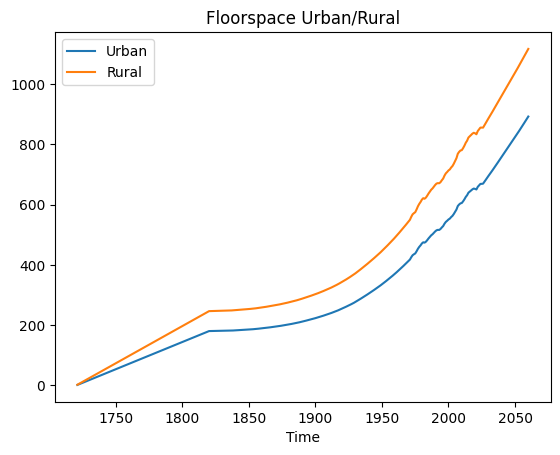

In [50]:
# Rural/Urban floorspace [Year, Region, Area]
floorspace_rururb = floorspace_commercial_rururb.sel({"Type": ["Urban", "Rural"]}).rename({"Type": "Area"})
floorspace_rururb.sum("Region").sel(Area="Urban").plot(label="Urban")
floorspace_rururb.sum("Region").sel(Area="Rural").plot(label="Rural")
plt.title("Floorspace Urban/Rural")
plt.legend()
plt.show()

In [51]:
# Commercial floorspace [Time, Region, Type]
floorspace_commercial = floorspace_commercial_rururb.sel(
    {"Type": [x.values for x in floorspace_commercial_rururb.coords["Type"] if x.values not in ["Urban", "Rural"]]})

#for commercial_type in floorspace_commercial.coords["Type"].values:
#    floorspace_commercial.sum("Region").sel(Type=commercial_type).plot(label=commercial_type)
    
#plt.legend()
#plt.title("Floorspace commercial")
#plt.show()

In [65]:
from imagematerials.buildings.preprocessing.population import compute_total_population

total_pop = compute_total_population(image_directory, base_directory)

Index(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
       '26'],
      dtype='object') Index([1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829,
       ...
       1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971],
      dtype='int64', name='year', length=152)


In [ ]:
# repairing this function: def compute_rurpop_share(image_directory):

In [62]:
# Get the population data [Year, Region, Area].
population = compute_population(image_directory, base_directory)
population.sum("Region").sel(Area="Urban").plot(label="Urban")
population.sum("Region").sel(Area="Rural").plot(label="Rural")
population.sum("Region").sel(Area="Total").plot(label="Total")
plt.title("Population (in millions)")
plt.legend()
plt.show()

Index(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
       '26'],
      dtype='object') Index([1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829,
       ...
       1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971],
      dtype='int64', name='year', length=152)


FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\raw\\image\\SSP2_CP\\rurpop.csv'

In [ ]:
# Average square meter per capita split by residential type [Region, Area, Type]
average_m2_capita = compute_average_m2_capita(base_directory)

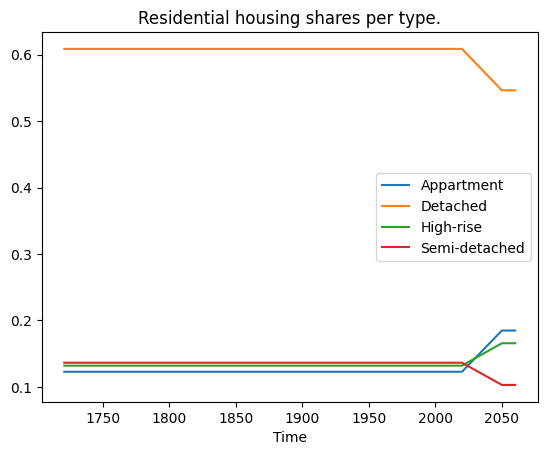

In [ ]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

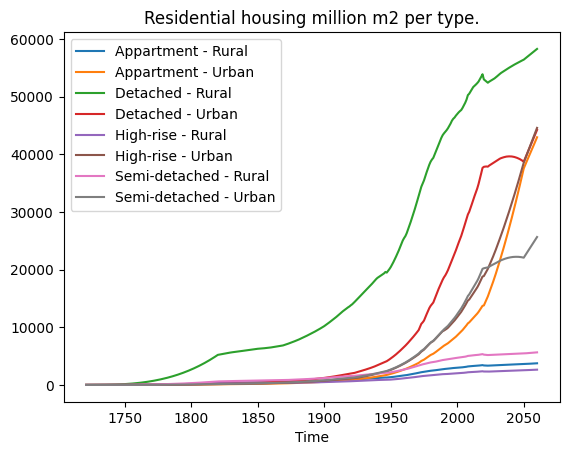

In [ ]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, average_m2_capita, housing_type, floorspace_rururb)

for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [ ]:

floorspace = xr.concat((floorspace_residential, floorspace_commercial), dim="Type")

In [ ]:
# Lifetime computations, see lifetimes.py

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes = compute_lifetimes(base_directory, floorspace_commercial.coords["Type"].values)

['Appartment', 'Detached', 'High-rise', 'Semi-detached']


In [ ]:
lifetimes["weibull"].coords["Type"]

<xarray.DataArray 'Type' (Type: 12)> Size: 96B
array(['Office', 'Retail+', 'Hotels+', 'Govt+', 'Appartment - Rural',
       'Appartment - Urban', 'Detached - Rural', 'Detached - Urban',
       'High-rise - Rural', 'High-rise - Urban', 'Semi-detached - Rural',
       'Semi-detached - Urban'], dtype=object)
Coordinates:
  * Type     (Type) object 96B 'Office' 'Retail+' ... 'Semi-detached - Urban'